## Imports

In [3]:
# ============================================================
# Notebook 7 - Final Evaluation & Analysis
# ============================================================

import os
import json
import pickle
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

from transformers import (
    AutoFeatureExtractor,
    Wav2Vec2ForSequenceClassification,
)

# ============================================================
# CPU Configuration
# ============================================================

NUM_THREADS = 4

os.environ["OMP_NUM_THREADS"] = str(NUM_THREADS)
os.environ["MKL_NUM_THREADS"] = str(NUM_THREADS)

torch.set_num_threads(NUM_THREADS)
torch.set_num_interop_threads(NUM_THREADS)

sns.set_theme(style="whitegrid")

# ============================================================
# Project Paths
# ============================================================

BASE_DIR = Path.cwd()
PROJECT_ROOT = BASE_DIR.parent.parent

MODEL_DIR = PROJECT_ROOT / "models" / "wav2vec2_ser"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
REPORT_DIR = OUTPUT_DIR / "reports"

REPORT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Device
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("Notebook 7 - Final Evaluation & Analysis")
print("=" * 70)

print(f"Device            : {DEVICE}")
print(f"CPU Threads       : {torch.get_num_threads()}")
print(f"Interop Threads   : {torch.get_num_interop_threads()}")

if DEVICE.type == "cuda":
    print(f"GPU               : {torch.cuda.get_device_name(0)}")

print("=" * 70)

Notebook 7 - Final Evaluation & Analysis
Device            : cpu
CPU Threads       : 4
Interop Threads   : 4


## Load Model

In [6]:
feature_extractor = AutoFeatureExtractor.from_pretrained(
    MODEL_DIR
)

model = Wav2Vec2ForSequenceClassification.from_pretrained(
    MODEL_DIR
)

model.to(DEVICE)
model.eval()

LABEL_ENCODER = PROJECT_ROOT / "outputs" / "label_encoder.pkl"

with open(LABEL_ENCODER, "rb") as f:
    label_encoder = pickle.load(f)    
print("Model Loaded")

Loading weights: 100%|██████████| 215/215 [00:00<00:00, 5843.16it/s]

Model Loaded


## Load Test Dataset


In [7]:
from datasets import load_from_disk

PREP_DIR = PROJECT_ROOT/"outputs"/"prepared_training"

test_dataset = load_from_disk(
    PREP_DIR/"test_dataset"
)

print(test_dataset)

Dataset({
    features: ['waveform', 'emotion', 'input_values', 'attention_mask', 'label'],
    num_rows: 288
})


## Predict Entire test set

In [8]:
y_true = []
y_pred = []

for sample in test_dataset:

    inputs = feature_extractor.pad(
        [{"input_values": sample["input_values"]}],
        return_tensors="pt"
    )

    inputs = {
        k:v.to(DEVICE)
        for k,v in inputs.items()
    }

    with torch.no_grad():

        logits = model(**inputs).logits

    prediction = torch.argmax(
        logits,
        dim=-1
    ).item()

    y_true.append(sample["label"])
    y_pred.append(prediction)

print("Prediction Completed")

Prediction Completed


## Classification Report

In [9]:
report = classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_,
    output_dict=True
)

report_df = pd.DataFrame(report).T

display(report_df)

report_df.to_csv(
    REPORT_DIR/"classification_report.csv"
)

/opt/homebrew/Caskroom/miniforge/base/envs/malaria_gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniforge/base/envs/malaria_gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniforge/base/envs/malaria_gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

,precision,recall,f1-score,support
angry,0.634146,0.684211,0.658228,38.000000
calm,0.411111,0.973684,0.578125,38.000000
disgust,0.380952,0.421053,0.400000,38.000000
fearful,0.454545,0.512821,0.481928,39.000000
happy,0.333333,0.025641,0.047619,39.000000
neutral,0.000000,0.000000,0.000000,19.000000
sad,0.312500,0.263158,0.285714,38.000000
surprised,0.583333,0.538462,0.560000,39.000000
accuracy,0.454861,0.454861,0.454861,0.454861
macro avg,0.388740,0.427379,0.376452,288.000000


## Confusion matrix


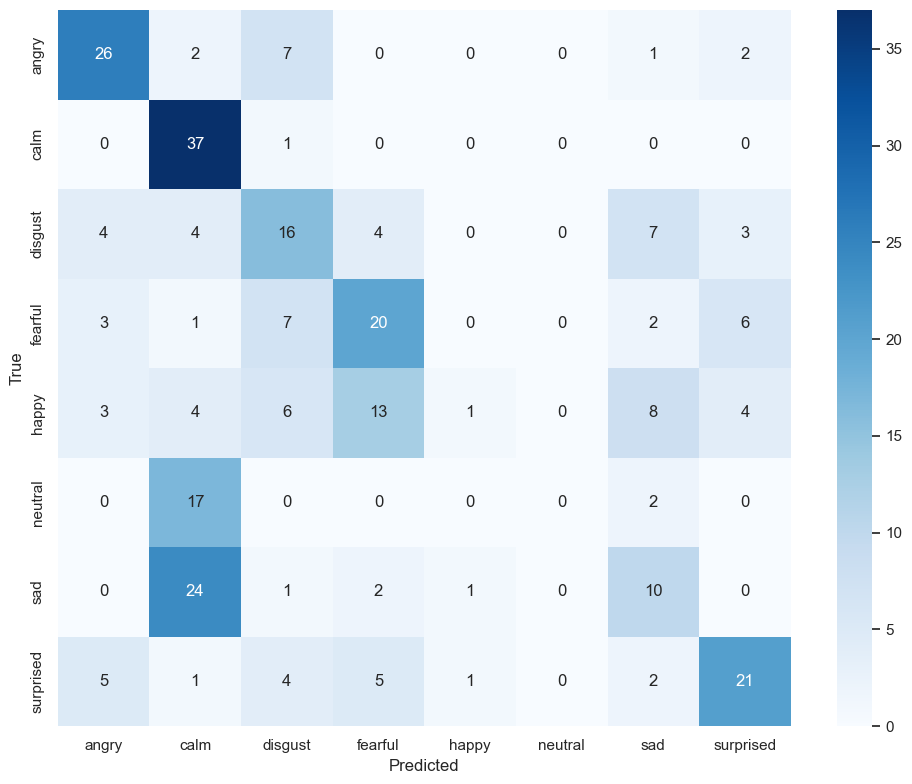

In [10]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")

plt.ylabel("True")

plt.tight_layout()

plt.show()

## Per-Class accurarcy


,precision,recall,f1-score
angry,0.634146,0.684211,0.658228
calm,0.411111,0.973684,0.578125
disgust,0.380952,0.421053,0.400000
fearful,0.454545,0.512821,0.481928
happy,0.333333,0.025641,0.047619
neutral,0.000000,0.000000,0.000000
sad,0.312500,0.263158,0.285714
surprised,0.583333,0.538462,0.560000


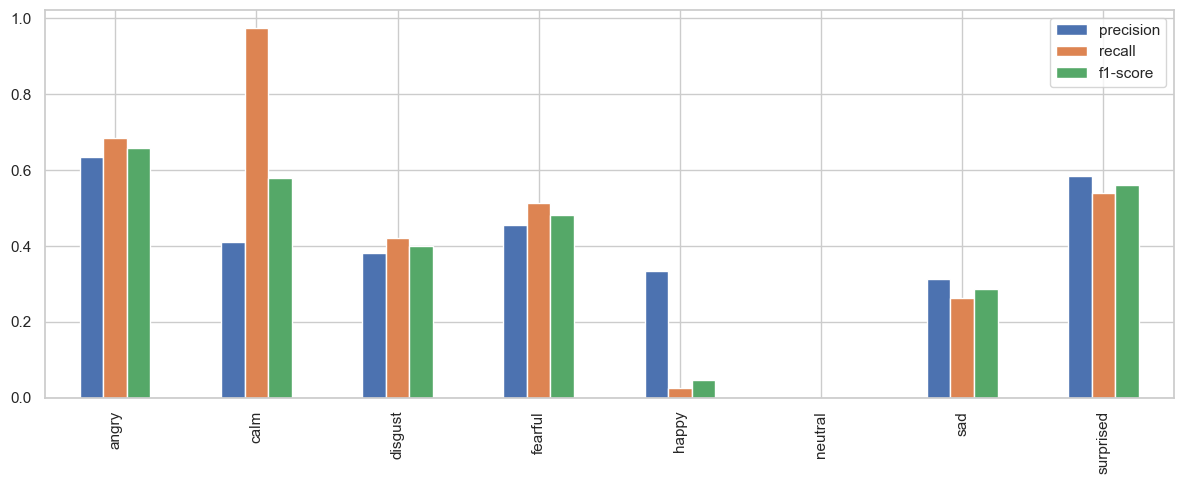

In [11]:
per_class = report_df.iloc[:-3][["precision","recall","f1-score"]]

display(per_class)

per_class.plot(
    kind="bar",
    figsize=(12,5)
)

plt.tight_layout()

plt.show()

## Prediction Distribution

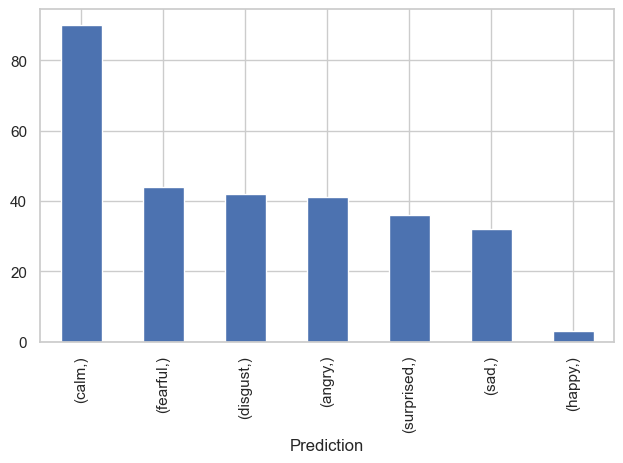

In [12]:
pred_df = pd.DataFrame({
    "Prediction":
    label_encoder.inverse_transform(
        y_pred
    )
})

pred_df.value_counts().plot(
    kind="bar"
)

plt.tight_layout()

plt.show()

## Misclassified Samples

In [13]:
errors=[]

for i,(t,p) in enumerate(zip(y_true,y_pred)):

    if t!=p:

        errors.append({

            "Index":i,

            "True":
            label_encoder.inverse_transform([t])[0],

            "Predicted":
            label_encoder.inverse_transform([p])[0]

        })

errors_df=pd.DataFrame(errors)

display(errors_df.head(20))

,Index,True,Predicted
0,0,sad,disgust
1,2,happy,calm
2,4,neutral,calm
3,6,angry,surprised
4,11,surprised,angry
5,15,disgust,angry
6,19,disgust,surprised
7,21,happy,calm
8,23,fearful,disgust
9,26,sad,calm


## Save final Report

In [14]:
results = {

    "accuracy":
    report["accuracy"],

    "macro avg":
    report["macro avg"],

    "weighted avg":
    report["weighted avg"]

}

with open(
    REPORT_DIR/"final_results.json",
    "w"
) as f:

    json.dump(
        results,
        f,
        indent=4
    )

print("Report Saved")

Report Saved


## Final Summary

In [15]:
print("="*70)

print("Speech Emotion Recognition")

print("="*70)

print("Dataset : RAVDESS")

print("Model : facebook/wav2vec2-base")

print("Classes :",len(label_encoder.classes_))

print("Accuracy :",report["accuracy"])

print()

print("Macro F1 :",report["macro avg"]["f1-score"])

print()

print("Weighted F1 :",report["weighted avg"]["f1-score"])

print("="*70)

Speech Emotion Recognition
Dataset : RAVDESS
Model : facebook/wav2vec2-base
Classes : 8
Accuracy : 0.4548611111111111

Macro F1 : 0.3764517365347466

Weighted F1 : 0.40114887036467145


## Notebook Complete 

In [16]:
print("="*70)
print("NOTEBOOK 7 COMPLETED SUCCESSFULLY")
print("="*70)

print("Completed")

print("✓ Test Prediction")
print("✓ Classification Report")
print("✓ Confusion Matrix")
print("✓ Per-Class Metrics")
print("✓ Error Analysis")
print("✓ Final Report Saved")

print("="*70)

NOTEBOOK 7 COMPLETED SUCCESSFULLY
Completed
✓ Test Prediction
✓ Classification Report
✓ Confusion Matrix
✓ Per-Class Metrics
✓ Error Analysis
✓ Final Report Saved
